In [10]:
# ============================================
# Cell 1: Imports & Seed
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import copy
import time
import os

from torchvision import datasets, transforms
from torchvision.models import (
    resnet18, resnet34,
    ResNet18_Weights, ResNet34_Weights
)

from torch.utils.data import DataLoader, Subset

import pandas as pd
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [11]:
# ============================================
# Cell 2: Config
# ============================================

CONFIG = {
    "dataset": "CIFAR10",
    "model_name": "resnet18",
    "batch_size": 128,
    "epochs": 3,
    "lr": 1e-3,

    "forget_mode": "class",
    "forget_classes": [0],

    "noise_std": 0.01
}
"""CONFIG = {
    "dataset": "CIFAR10",      # CIFAR10 or CIFAR100
    "model_name": "resnet18",  # resnet18 or resnet34
    "batch_size": 128,
    "epochs": 5,
    "lr": 1e-3,

    "forget_mode": "class",    # class or random
    "forget_classes": [0],     # удаляем 1 класс
    "forget_ratio": 0.01,

    "noise_std": 0.01
}"""

device = "cuda" if torch.cuda.is_available() else "cpu"

# random seeds for statistical stability
SEEDS = [0,1,2]

In [12]:
# ============================================
# Cell 3: Dataset (CIFAR only)
# ============================================

transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

if CONFIG["dataset"] == "CIFAR10":

    train_dataset = datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=transform
    )

    test_dataset = datasets.CIFAR10(
        root="./data",
        train=False,
        download=True,
        transform=transform
    )

    num_classes = 10


elif CONFIG["dataset"] == "CIFAR100":

    train_dataset = datasets.CIFAR100(
        root="./data",
        train=True,
        download=True,
        transform=transform
    )

    test_dataset = datasets.CIFAR100(
        root="./data",
        train=False,
        download=True,
        transform=transform
    )

    num_classes = 100

In [13]:
# ============================================
# Cell 4: Split Forget / Retain
# ============================================

indices = list(range(len(train_dataset)))

labels = np.array([train_dataset[i][1] for i in range(len(train_dataset))])

if CONFIG["forget_mode"] == "class":

    forget_idx = np.where(
        np.isin(labels, CONFIG["forget_classes"])
    )[0]

    retain_idx = np.where(
        ~np.isin(labels, CONFIG["forget_classes"])
    )[0]

else:

    np.random.shuffle(indices)

    split = int(len(indices) * CONFIG["forget_ratio"])

    forget_idx = indices[:split]
    retain_idx = indices[split:]

forget_dataset = Subset(train_dataset, forget_idx)
retain_dataset = Subset(train_dataset, retain_idx)

train_loader = DataLoader(train_dataset,
                          batch_size=CONFIG["batch_size"],
                          shuffle=True)

forget_loader = DataLoader(forget_dataset,
                           batch_size=CONFIG["batch_size"],
                           shuffle=True)

retain_loader = DataLoader(retain_dataset,
                           batch_size=CONFIG["batch_size"],
                           shuffle=True)

test_loader = DataLoader(test_dataset,
                         batch_size=CONFIG["batch_size"])

print("Train:", len(train_dataset))
print("Forget:", len(forget_dataset))
print("Retain:", len(retain_dataset))

Train: 50000
Forget: 5000
Retain: 45000


In [14]:
# ============================================
# Cell 5: Model
# ============================================

def get_model():

    if CONFIG["model_name"] == "resnet18":
        model = resnet18(weights=ResNet18_Weights.DEFAULT)

    elif CONFIG["model_name"] == "resnet34":
        model = resnet34(weights=ResNet34_Weights.DEFAULT)

    else:
        raise ValueError("Unknown model")

    # adaptation for CIFAR
    model.conv1 = nn.Conv2d(
        3, 64, kernel_size=3, stride=1, padding=1, bias=False
    )

    model.maxpool = nn.Identity()

    model.fc = nn.Linear(
        model.fc.in_features,
        num_classes
    )

    return model.to(device)

In [15]:
# ============================================
# Cell 6: Train & Evaluate
# ============================================

def train(model, loader, name="Model"):

    optimizer = optim.Adam(
        model.parameters(),
        lr=CONFIG["lr"]
    )

    criterion = nn.CrossEntropyLoss()

    print(f"\n{name} training")

    for epoch in range(CONFIG["epochs"]):

        model.train()

        correct = 0
        total = 0

        for x,y in loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            out = model(x)

            loss = criterion(out,y)

            loss.backward()

            optimizer.step()

            preds = out.argmax(1)

            correct += (preds==y).sum().item()

            total += y.size(0)

        acc = correct/total

        print(f"Epoch {epoch+1}: {acc:.3f}")

    return model


def evaluate(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x,y in loader:

            x = x.to(device)
            y = y.to(device)

            preds = model(x).argmax(1)

            correct += (preds==y).sum().item()

            total += y.size(0)

    return correct/total

In [16]:
# ============================================
# Cell 7: Unlearning methods
# ============================================

def gradient_ascent(model):

    model = copy.deepcopy(model)

    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    criterion = nn.CrossEntropyLoss()

    for _ in range(CONFIG["epochs"]):

        for x,y in forget_loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            loss = criterion(model(x),y)

            (-loss).backward()

            optimizer.step()

    return model


def random_labels(model):

    model = copy.deepcopy(model)

    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    criterion = nn.CrossEntropyLoss()

    for _ in range(CONFIG["epochs"]):

        for x,y in forget_loader:

            x = x.to(device)

            rand = torch.randint(
                0,
                num_classes,
                y.shape
            ).to(device)

            optimizer.zero_grad()

            loss = criterion(model(x), rand)

            loss.backward()

            optimizer.step()

    return model


def reset_last_layer(model):

    # работаем с копией модели
    model = copy.deepcopy(model)

    model.train()

    # замораживаем все параметры
    for p in model.parameters():
        p.requires_grad = False

    # сохраняем размер входа последнего слоя
    in_features = model.fc.in_features

    # переинициализируем последний слой
    model.fc = nn.Linear(in_features, num_classes).to(device)

    # включаем обучение только для него
    for p in model.fc.parameters():
        p.requires_grad = True

    optimizer = optim.Adam(
        model.fc.parameters(),
        lr=1e-3
    )

    criterion = nn.CrossEntropyLoss()

    # обучаем только последний слой
    for epoch in range(CONFIG["epochs"]):

        for x, y in retain_loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            outputs = model(x)

            loss = criterion(outputs, y)

            loss.backward()

            optimizer.step()

    return model


def add_noise(model):

    model = copy.deepcopy(model)

    with torch.no_grad():

        for p in model.parameters():

            p += CONFIG["noise_std"] * torch.randn_like(p)

    return model

In [17]:
# ============================================
# Cell 8: Experiment Loop (FIXED)
# ============================================

all_records = []

for seed in SEEDS:

    print("\n===================")
    print("Seed:", seed)
    print("===================")

    set_seed(seed)

    # train base model
    base_model = get_model()
    base_model = train(base_model, train_loader, "Base")

    # retrain baseline
    retrain_model = get_model()
    retrain_model = train(retrain_model, retain_loader, "Retrain")

    # store models
    models = {
        "Base": copy.deepcopy(base_model),
        "Retrain": retrain_model,

        "Gradient Ascent": gradient_ascent(copy.deepcopy(base_model)),
        "Random Labels": random_labels(copy.deepcopy(base_model)),
        "Reset Layers": reset_last_layer(copy.deepcopy(base_model)),
        "Noise": add_noise(copy.deepcopy(base_model))
    }

    # evaluation
    for name, model in models.items():

        acc_f = evaluate(model, forget_loader)
        acc_r = evaluate(model, retain_loader)
        acc_test = evaluate(model, test_loader)

        all_records.append({
            "Seed": seed,
            "Method": name,
            "Acc_F": acc_f,
            "Acc_R": acc_r,
            "Test_Acc": acc_test
        })


Seed: 0

Base training
Epoch 1: 0.748
Epoch 2: 0.870
Epoch 3: 0.912

Retrain training
Epoch 1: 0.771
Epoch 2: 0.883
Epoch 3: 0.924

Seed: 1

Base training
Epoch 1: 0.754
Epoch 2: 0.875
Epoch 3: 0.918

Retrain training
Epoch 1: 0.764
Epoch 2: 0.880
Epoch 3: 0.918

Seed: 2

Base training
Epoch 1: 0.742
Epoch 2: 0.872
Epoch 3: 0.917

Retrain training
Epoch 1: 0.758
Epoch 2: 0.877
Epoch 3: 0.919


In [18]:
# ============================================
# Cell 9: Aggregation
# ============================================

df = pd.DataFrame(all_records)

summary = df.groupby("Method").agg(
    Acc_F_mean=("Acc_F","mean"),
    Acc_F_std=("Acc_F","std"),
    Acc_R_mean=("Acc_R","mean"),
    Acc_R_std=("Acc_R","std"),
    Test_mean=("Test_Acc","mean"),
    Test_std=("Test_Acc","std")
).reset_index()

print(summary)

            Method  Acc_F_mean  Acc_F_std  Acc_R_mean  Acc_R_std  Test_mean  \
0             Base    0.973867   0.011455    0.939244   0.002927   0.865400   
1  Gradient Ascent    0.000000   0.000000    0.501719   0.061290   0.440767   
2            Noise    0.964533   0.025426    0.919222   0.015558   0.847867   
3    Random Labels    0.111400   0.029456    0.874719   0.022561   0.728333   
4     Reset Layers    0.000000   0.000000    0.968178   0.001806   0.804367   
5          Retrain    0.000000   0.000000    0.940378   0.007041   0.782700   

   Test_std  
0  0.002443  
1  0.049750  
2  0.011151  
3  0.016546  
4  0.001159  
5  0.007144  


In [19]:
# ============================================
# Cell 10: Pretty Table
# ============================================

summary["Acc_F"] = summary["Acc_F_mean"].round(3).astype(str) + " ± " + summary["Acc_F_std"].round(3).astype(str)

summary["Acc_R"] = summary["Acc_R_mean"].round(3).astype(str) + " ± " + summary["Acc_R_std"].round(3).astype(str)

summary["Test"] = summary["Test_mean"].round(3).astype(str) + " ± " + summary["Test_std"].round(3).astype(str)

final_table = summary[["Method","Acc_F","Acc_R","Test"]]

print(final_table)

            Method          Acc_F          Acc_R           Test
0             Base  0.974 ± 0.011  0.939 ± 0.003  0.865 ± 0.002
1  Gradient Ascent      0.0 ± 0.0  0.502 ± 0.061   0.441 ± 0.05
2            Noise  0.965 ± 0.025  0.919 ± 0.016  0.848 ± 0.011
3    Random Labels  0.111 ± 0.029  0.875 ± 0.023  0.728 ± 0.017
4     Reset Layers      0.0 ± 0.0  0.968 ± 0.002  0.804 ± 0.001
5          Retrain      0.0 ± 0.0   0.94 ± 0.007  0.783 ± 0.007


In [20]:
# ============================================
# Cell 11: Save Results with Informative Name
# ============================================

from datetime import datetime

os.makedirs("results", exist_ok=True)

# короткое имя модели
model_short = CONFIG["model_name"].replace("resnet", "r")

# короткое имя режима
mode_short = "cls" if CONFIG["forget_mode"] == "class" else "rnd"

# forget classes строкой
forget_str = "-".join(map(str, CONFIG["forget_classes"]))

# timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# имя файла
filename = (
    f"{model_short}_"
    f"{CONFIG['dataset']}_"
    f"{mode_short}_"
    f"f{forget_str}_"
    f"ep{CONFIG['epochs']}_"
    f"bs{CONFIG['batch_size']}_"
    f"lr{CONFIG['lr']}_"
    f"s{len(SEEDS)}_"
    f"{timestamp}"
)

csv_path = f"results/{filename}.csv"

summary.to_csv(csv_path, index=False)

print("Saved:", csv_path)

Saved: results/r18_CIFAR10_cls_f0_ep3_bs128_lr0.001_s3_20260410_104634.csv


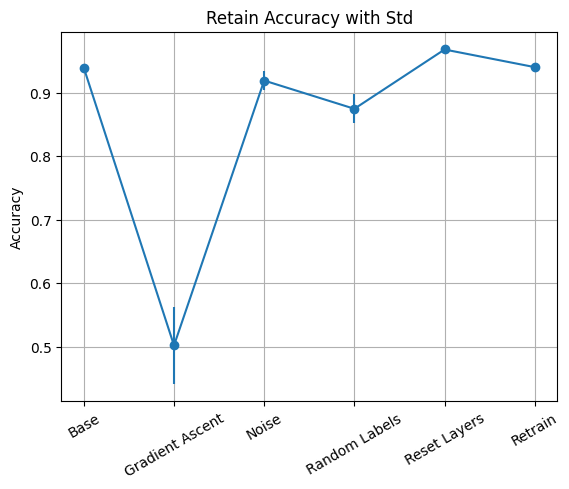

In [21]:
# ============================================
# Cell 12: Visualization
# ============================================

plt.figure()

plt.errorbar(
    summary["Method"],
    summary["Acc_R_mean"],
    yerr=summary["Acc_R_std"],
    marker='o'
)

plt.title("Retain Accuracy with Std")

plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.grid(True)

plt.show()